<a href="https://colab.research.google.com/github/xujiahengbill-bot/Harris/blob/main/Chenmed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'D:\ChenMed\patients.csv')
df.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,a026e2aa-baad-ec8f-6467-cc1d551b07f1,1986-02-14,NaN,999-54-2351,S99936372,X34529171X,Mrs.,Dorathy429,Rosita520,Bashirian201,...,Tampa,Florida,Hillsborough County,12057.0,33611,28.013581,-82.456366,110471.32,118799.60,11534
1,b9edfa61-85ea-6752-e4f9-82eed5795971,2018-02-17,NaN,999-88-3100,NaN,NaN,NaN,Jeanna557,Deborah357,Okuneva707,...,Miami,Florida,Miami-Dade County,12086.0,33139,25.790868,-80.210928,1350.00,24257.33,2291
2,aee01659-fd4a-816d-9a82-d6bd261e5e60,2011-01-28,NaN,999-78-5694,NaN,NaN,NaN,Rolando809,Sean831,White193,...,Yulee,Florida,Nassau County,12089.0,32097,30.628132,-81.613197,45379.43,11799.66,49750
3,94e9305c-e5b4-86f1-d919-ed68d46ede7d,2012-12-11,NaN,999-16-4825,NaN,NaN,NaN,Krystyna791,Joella167,Bergstrom287,...,Wellington,Florida,Palm Beach County,12099.0,33449,26.693884,-80.305558,46194.18,16989.84,147243
4,37f97377-749d-673a-adb6-08a3d40fd462,1980-11-02,NaN,999-13-2132,S99993697,X43073450X,Mr.,Charlie254,Norbert530,Jenkins714,...,Ives Estates,Florida,Miami-Dade County,NaN,0,25.932489,-80.218032,152153.83,11940.70,37492


In [ ]:
df1 = pd.read_csv(r'D:\ChenMed\encounters.csv')
df1.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,a69261e5-27fc-966e-4069-13f1e2a0b869,2004-04-10T03:19:48Z,2004-04-10T04:10:56Z,a026e2aa-baad-ec8f-6467-cc1d551b07f1,a150a318-53fc-3731-ab58-8bf301fd7ce0,d05795c2-efa5-392d-b41b-36e46dcc5963,df166300-5a78-3502-a46a-832842197811,wellness,162673000,General examination of patient (procedure),163.63,1223.40,1073.4,NaN,NaN
1,49b03704-d808-e829-1e0d-a344b90cbbcc,2011-04-23T03:19:48Z,2011-04-23T04:15:45Z,a026e2aa-baad-ec8f-6467-cc1d551b07f1,a150a318-53fc-3731-ab58-8bf301fd7ce0,d05795c2-efa5-392d-b41b-36e46dcc5963,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),163.63,2147.18,0.0,NaN,NaN
2,ec196aa1-e402-961c-a292-9d424f9a0e1c,2011-12-27T15:00:16Z,2011-12-28T15:00:16Z,a026e2aa-baad-ec8f-6467-cc1d551b07f1,c78c7864-ccbe-31e2-a321-a2cc6a18df56,22b3b395-a43d-3031-a871-694787986b13,e03e23c9-4df1-3eb6-a62d-f70f02301496,inpatient,305408004,Admission to surgical department (procedure),108.86,19226.24,0.0,183996000.0,Sterilization requested (situation)
3,a87a159e-e2dd-e2c5-0772-f66c167304d2,2014-04-26T03:19:48Z,2014-04-26T03:57:43Z,a026e2aa-baad-ec8f-6467-cc1d551b07f1,a150a318-53fc-3731-ab58-8bf301fd7ce0,d05795c2-efa5-392d-b41b-36e46dcc5963,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,wellness,162673000,General examination of patient (procedure),163.63,1429.54,0.0,NaN,NaN
4,a8b62382-dc0c-fafa-e2e2-8bfb45c31c6f,2015-05-30T03:19:48Z,2015-05-30T04:18:23Z,a026e2aa-baad-ec8f-6467-cc1d551b07f1,8c19643a-4bb6-3d34-bd6b-c85c5621d232,30e5059f-25e0-3ec6-956f-3244ae1e3b82,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,urgentcare,702927004,Urgent care clinic (environment),106.81,858.66,0.0,NaN,NaN


In [ ]:
df2 = pd.read_csv(r'D:\ChenMed\conditions.csv')
df2.head()

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2004-04-10,NaN,a026e2aa-baad-ec8f-6467-cc1d551b07f1,a69261e5-27fc-966e-4069-13f1e2a0b869,http://snomed.info/sct,224299000,Received higher education (finding)
1,2011-04-23,2023-05-06,a026e2aa-baad-ec8f-6467-cc1d551b07f1,49b03704-d808-e829-1e0d-a344b90cbbcc,http://snomed.info/sct,73595000,Stress (finding)
2,2011-04-23,NaN,a026e2aa-baad-ec8f-6467-cc1d551b07f1,49b03704-d808-e829-1e0d-a344b90cbbcc,http://snomed.info/sct,10939881000119105,Unhealthy alcohol drinking behavior (finding)
3,2011-12-27,NaN,a026e2aa-baad-ec8f-6467-cc1d551b07f1,ec196aa1-e402-961c-a292-9d424f9a0e1c,http://snomed.info/sct,267020005,History of tubal ligation (situation)
4,2014-04-25,2017-04-29,a026e2aa-baad-ec8f-6467-cc1d551b07f1,a87a159e-e2dd-e2c5-0772-f66c167304d2,http://snomed.info/sct,160904001,Part-time employment (finding)


In [ ]:
df3 = pd.read_csv(r'D:\ChenMed\ICD-10_New.csv')
df3.head(10)
list(df3)

['ICD10',
 'ICD10_Description',
 'Non_Emergent',
 'Emergent__PC_Treatable',
 'ED_Care_Needed__Preventable_Avoi',
 'ED_Care_Needed__not_Preventable',
 'Alcohol',
 'Drug',
 'Injury',
 'Psych',
 'Unclassified']

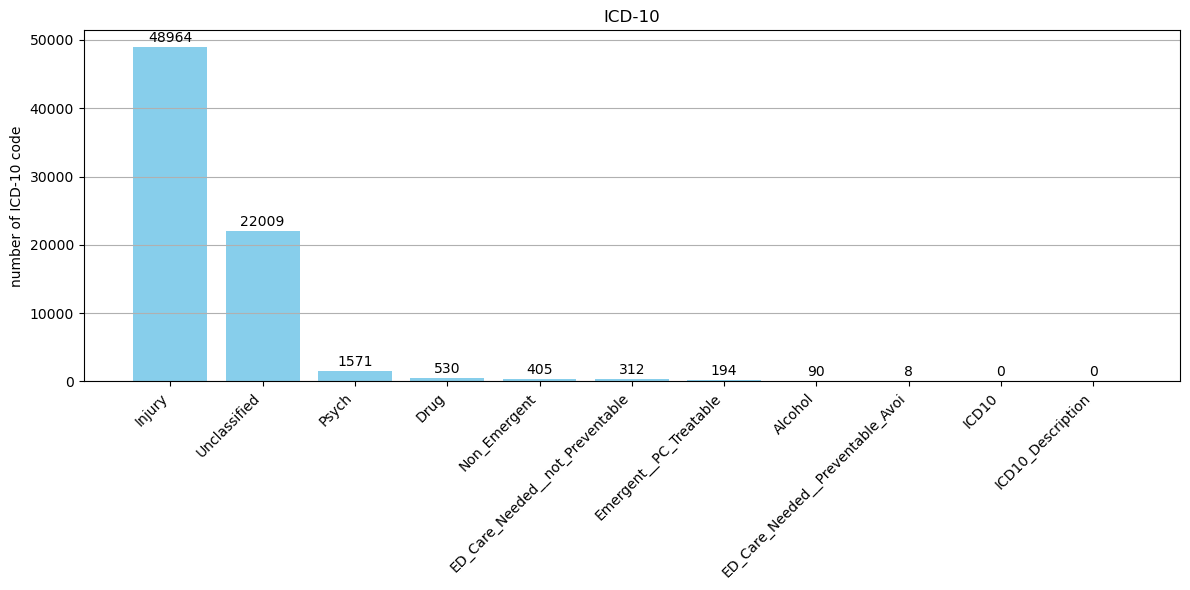

In [ ]:
# Count number of those dummy variable
category_counts = {col: (df3[col] == 1.0).sum() for col in df3.columns}
category_series = pd.Series(category_counts).sort_values(ascending=False)

# plot it
plt.figure(figsize=(12, 6))
bars = plt.bar(category_series.index, category_series.values, color='skyblue')
plt.title("ICD-10")
plt.ylabel("number of ICD-10 code")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 300, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.show()

In [ ]:
category_cols = ['Alcohol', 'Drug', 'Injury', 'Psych', 'Unclassified']


df3['category_sum'] = df3[category_cols].sum(axis=1)

multi_label_df = df3[df3['category_sum'] > 1]
display(multi_label_df[['ICD10', 'ICD10_Description'] + category_cols].head(20))

,ICD10,ICD10_Description,Alcohol,Drug,Injury,Psych,Unclassified


In [ ]:
df_1 = df1.merge(
    df, left_on='PATIENT', right_on='Id', suffixes=('_encounter', '_patient')
)
df_1.head()
list(df_1)

['Id_encounter',
 'START',
 'STOP',
 'PATIENT',
 'ORGANIZATION',
 'PROVIDER',
 'PAYER',
 'ENCOUNTERCLASS',
 'CODE',
 'DESCRIPTION',
 'BASE_ENCOUNTER_COST',
 'TOTAL_CLAIM_COST',
 'PAYER_COVERAGE',
 'REASONCODE',
 'REASONDESCRIPTION',
 'Id_patient',
 'BIRTHDATE',
 'DEATHDATE',
 'SSN',
 'DRIVERS',
 'PASSPORT',
 'PREFIX',
 'FIRST',
 'MIDDLE',
 'LAST',
 'SUFFIX',
 'MAIDEN',
 'MARITAL',
 'RACE',
 'ETHNICITY',
 'GENDER',
 'BIRTHPLACE',
 'ADDRESS',
 'CITY',
 'STATE',
 'COUNTY',
 'FIPS',
 'ZIP',
 'LAT',
 'LON',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE',
 'INCOME']

In [ ]:
keep_cols = [
    'PATIENT',
    'START',
    'ENCOUNTERCLASS',
    'CODE',
    'DESCRIPTION',
    'BASE_ENCOUNTER_COST',
    'TOTAL_CLAIM_COST',
    'PAYER_COVERAGE',
    'BIRTHDATE',
    'GENDER',
    'RACE',
    'ETHNICITY',
    'INCOME'
]
df_cleaned = df_1[keep_cols].copy()

df_cleaned.head()

,PATIENT,START,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,BIRTHDATE,GENDER,RACE,ETHNICITY,INCOME
0,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2004-04-10T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1223.40,1073.4,1986-02-14,F,white,nonhispanic,11534
1,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-04-23T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,2147.18,0.0,1986-02-14,F,white,nonhispanic,11534
2,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-12-27T15:00:16Z,inpatient,305408004,Admission to surgical department (procedure),108.86,19226.24,0.0,1986-02-14,F,white,nonhispanic,11534
3,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2014-04-26T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1429.54,0.0,1986-02-14,F,white,nonhispanic,11534
4,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2015-05-30T03:19:48Z,urgentcare,702927004,Urgent care clinic (environment),106.81,858.66,0.0,1986-02-14,F,white,nonhispanic,11534


In [ ]:
df2['START'] = pd.to_datetime(df2['START'])

# each patient only repersent one column
df2_first_condition = df2.sort_values('START').drop_duplicates(subset='PATIENT', keep='first')

# keep the code and groupby ICD code
df_merged = df_cleaned.merge(
    df2_first_condition[['PATIENT', 'CODE', 'DESCRIPTION']],
    on='PATIENT',
    how='left',
    suffixes=('', '_condition')
)

df_merged.head()

,PATIENT,START,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,BIRTHDATE,GENDER,RACE,ETHNICITY,INCOME,CODE_condition,DESCRIPTION_condition
0,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2004-04-10T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1223.40,1073.4,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding)
1,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-04-23T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,2147.18,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding)
2,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-12-27T15:00:16Z,inpatient,305408004,Admission to surgical department (procedure),108.86,19226.24,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding)
3,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2014-04-26T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1429.54,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding)
4,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2015-05-30T03:19:48Z,urgentcare,702927004,Urgent care clinic (environment),106.81,858.66,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding)


In [ ]:
map_df = pd.read_csv(r'D:\ChenMed\tls_Icd10cmHumanReadableMap_US1000124_20250301.tsv', sep='\t')

# filtered
map_filtered = map_df[
    (map_df['mapGroup'] == 1) &
    (map_df['mapTarget'].notnull()) &
    (map_df['mapTarget'] != '')
][['referencedComponentId', 'mapTarget']].drop_duplicates()

# mapping
snomed_to_icd10 = dict(zip(map_filtered['referencedComponentId'].astype(str), map_filtered['mapTarget']))

# conponent
df_merged['ICD10'] = df_merged['CODE_condition'].astype(str).map(snomed_to_icd10)

In [ ]:
df_merged[['CODE_condition', 'DESCRIPTION_condition', 'ICD10']].drop_duplicates().head(10)

,CODE_condition,DESCRIPTION_condition,ICD10
0,224299000,Received higher education (finding),NaN
18,314529007,Medication review due (situation),Z76.89
137,473461003,Educated to high school level (finding),NaN
172,233678006,Childhood asthma (disorder),J45.909
238,40055000,Chronic sinusitis (disorder),J32.9
347,160968000,Risk activity involvement (finding),Z91.89
421,428251008,History of appendectomy (situation),Z90.49
626,73595000,Stress (finding),Z73.3
904,161744009,Past pregnancy history of miscarriage (situation),Z87.59
943,197927001,Recurrent urinary tract infection (disorder),N39.0


In [ ]:
missing_mappings = df_merged[df_merged['ICD10'].isna()][['CODE_condition', 'DESCRIPTION_condition']].drop_duplicates()
print("failure of conversion SNOMED code counts：", missing_mappings.shape[0])
missing_mappings.head(10)

failure of conversion SNOMED code counts： 8


,CODE_condition,DESCRIPTION_condition
0,224299000,Received higher education (finding)
137,473461003,Educated to high school level (finding)
1572,446654005,Refugee (person)
7952,160903007,Full-time employment (finding)
8933,1187604002,Serving in military service (finding)
263322,6525002,Dependent drug abuse (disorder)
304077,384709000,Sprain (morphologic abnormality)
737140,160904001,Part-time employment (finding)


In [ ]:
df_merged['ICD10'] = df_merged['ICD10'].fillna('UNKNOWN')
df_merged.head()

,PATIENT,START,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,BIRTHDATE,GENDER,RACE,ETHNICITY,INCOME,CODE_condition,DESCRIPTION_condition,ICD10
0,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2004-04-10T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1223.40,1073.4,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding),UNKNOWN
1,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-04-23T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,2147.18,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding),UNKNOWN
2,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2011-12-27T15:00:16Z,inpatient,305408004,Admission to surgical department (procedure),108.86,19226.24,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding),UNKNOWN
3,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2014-04-26T03:19:48Z,wellness,162673000,General examination of patient (procedure),163.63,1429.54,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding),UNKNOWN
4,a026e2aa-baad-ec8f-6467-cc1d551b07f1,2015-05-30T03:19:48Z,urgentcare,702927004,Urgent care clinic (environment),106.81,858.66,0.0,1986-02-14,F,white,nonhispanic,11534,224299000,Received higher education (finding),UNKNOWN


In [ ]:
# count number of unknown
unknown_count = (df_merged['ICD10'] == 'UNKNOWN').sum()

# total count
total_count = df_merged.shape[0]

# outcome
print(f" can't be matched ICD-10 Numbers: {unknown_count} / {total_count}")
print(f" %: {unknown_count / total_count:.2%}")

❓ 无法匹配的 ICD-10 记录数量: 352487 / 926514
❓ 占比: 38.04%
